# **Proyecto Integrador**

---

### 📌 Contexto del proyecto

**InsightReach** es una empresa de marketing digital especializada en el diseño de campañas personalizadas para negocios locales.

Con el crecimiento de su base de clientes y la expansión hacia nuevos mercados, surge la necesidad de **optimizar las estrategias de segmentación** para mejorar la efectividad de las campañas y maximizar el impacto en audiencias específicas.

En este contexto, se plantea un reto técnico orientado al rol de **Científico de Datos Junior**, cuyo propósito es demostrar la capacidad de integrar múltiples fuentes de datos, analizarlas y transformarlas en **insights accionables** que apoyen la toma de decisiones de negocio.

---

### 🧠 Rol asumido en el proyecto

En este proyecto se asume el rol de **Científico de Datos Junior**, con las siguientes responsabilidades:

- Explorar y comprender estructuras de datos reales provenientes de distintas fuentes.
- Realizar procesos de limpieza y transformación de datos para garantizar su calidad.
- Aplicar técnicas de Análisis Exploratorio de Datos (EDA) utilizando:
  - `pandas`
  - `numpy`
- Enriquecer el análisis mediante la conexión con fuentes externas de información.
- Interpretar los resultados obtenidos para generar recomendaciones útiles para el negocio.
- Documentar el proceso de manera clara, estructurada y reproducible.

---

### 🔎 Enfoque del análisis

Aunque el objetivo final del proyecto será trabajar con **una ciudad específica**, en esta primera etapa se desarrollará un
 **(EDA)** general considerando la totalidad de los datos disponibles.

Este enfoque permite:

- Comprender la estructura global del dataset.
- Detectar patrones, inconsistencias y oportunidades de limpieza.
- Identificar criterios para seleccionar la ciudad más adecuada en etapas posteriores.

---



##  Análisis Exploratorio
---

### 1️ Carga y exploración de datos

Se realiza la carga del dataset y una revisión inicial para comprender:

- Dimensiones del dataset.
- Tipos de datos por columna.
- Posibles valores nulos o inconsistencias.
- Qué representa cada variable.


In [1]:
#importamos librerías que vamos a usar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1) Primeros datos

In [2]:
#carga
df= pd.read_csv("base_datos_restaurantes_USA_v2.csv")
display(df.head())



,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


### 1.2) Información general del DataFrame
Revisamos los tipos de datos y cuantos valores null hay

In [3]:
#Dimensiones del DataFrame
print ("dimensiones: ",df.shape) #<- .shape indica las dimensiones de un objeto(filas y columnas)
#Tipos de datos y nulos
df.info()

#En este caso estamos hablando de un D.F de 30000 registros 

dimensiones:  (30000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto   

### 1.3) Estadística Descriptiva
Revisamos los valores estadísticos básicos de la columna númerica para indentificar algún outlier.
En este caso nos encontramos con valores atípicos en las columnas "Edad" "Frecuencia_visita" "promedio_gasto_comida"


In [4]:
df.describe() #<- .describe genera un resumen estadístico rápido del D.F


,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.000000,30000.000000,29855.000000,30000.000000
mean,5.504765e+09,49.665006,3.896133,32.603452,5389.755867
std,2.602799e+09,23.839550,2.741532,26.402601,4538.491728
min,1.000153e+09,-5.000000,-3.000000,0.000000,800.000000
25%,3.243617e+09,33.000000,2.000000,13.290000,1860.000000
50%,5.515865e+09,49.000000,4.000000,25.510000,3402.000000
75%,7.754426e+09,65.000000,5.000000,44.400000,7761.000000
max,9.999627e+09,300.000000,10.000000,149.970000,17999.000000


In [5]:
#¿Cuántos registros tienen edad inválida?
print("edades_negativas: ",(df["edad"]<0).sum())
print("edad mayores a 100: ",(df["edad"]>100).sum())

#¿Cuántos registros tienen frecuencia negativa?
print("Frecuencia negativa: ",(df["frecuencia_visita"]<0).sum())

#¿Cuántos gastos están en 0?
print("Gasto igual a 0: ",(df["promedio_gasto_comida"]==0).sum())

edades_negativas:  97
edad mayores a 100:  110
Frecuencia negativa:  1547
Gasto igual a 0:  1463


In [6]:
#Hacemos un conteo de "edad" para conocer cuántas veces se repiten estos outliers
print(df["edad"].value_counts().sort_index())

edad
-5.0       97
 18.0     457
 19.0     484
 20.0     449
 21.0     464
         ... 
 77.0     509
 78.0     444
 79.0     487
 80.0     483
 300.0    110
Name: count, Length: 65, dtype: int64


In [7]:
#Hacemos un conteo de "frecuencia_visita" para conocer cuántas veces se repiten estos outliers
df[df["frecuencia_visita"]<0]["frecuencia_visita"].value_counts()

frecuencia_visita
-3    1547
Name: count, dtype: int64

### 1.4) Mostrar problemas encontrados
mostramos los problemas encontrados

In [8]:
print ("=====Problemas detectados en el DataFrame=====\n")
print ("Valores Erroneos:")
print (f" - Edad con valor -5 (centinela): {(df["edad"] == -5).sum()} registros")
print (f" - Edad con valor 300 (error captura): {(df["edad"] == 300).sum()} registros")
print (f" - Frecuencia de visita con valor -3 (centinela): {(df["frecuencia_visita"] == -3).sum()} registros")
print (f" - Promedio gasto de comida 0: {(df["promedio_gasto_comida"] == 0).sum()} registros")

print("\nVALORES NULOS:")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos.to_string())
print("_______________________________________________")

=====Problemas detectados en el DataFrame=====

Valores Erroneos:
 - Edad con valor -5 (centinela): 97 registros
 - Edad con valor 300 (error captura): 110 registros
 - Frecuencia de visita con valor -3 (centinela): 1547 registros
 - Promedio gasto de comida 0: 1463 registros

VALORES NULOS:
telefono_contacto            15166
correo_electronico           15072
preferencias_alimenticias     1403
promedio_gasto_comida          145
edad                           101
_______________________________________________


### 1.5 Limpieza de datos

Se reemplazan los valores centinela (-5 en edad, -3 en frecuencia_visita) y los errores de captura (300 en edad) por NaN, ya que no representan datos reales. Posteriormente se imputan con la mediana por ser menos sensible a valores extremos.

In [9]:
import numpy as np

In [10]:
#Remplazar los valores por NaN
df["edad"]=df["edad"].replace([-5,300], np.nan)
df["frecuencia_visita"]=df["frecuencia_visita"].replace (-3, np.nan)

#Verificar que quedaron los cambios
print("Nulos en edad después de limpieza: ",df["edad"].isnull().sum())
print("Nulos en frecuencia de visita después de limpieza: ",df["frecuencia_visita"].isnull().sum())

Nulos en edad después de limpieza:  308
Nulos en frecuencia de visita después de limpieza:  1547


In [11]:
#Imputar con la mediana
df["edad"]=df["edad"].fillna(df["edad"].median())
df["frecuencia_visita"]=df["frecuencia_visita"].fillna(df["frecuencia_visita"].median())

#Verificar que no quedaron nulos
print("Nulos en edad después de imputar: ",df ["edad"].isnull().sum())
print("Nulos en frecuencia de visita después de imputar",df ["frecuencia_visita"].isnull().sum())

Nulos en edad después de imputar:  0
Nulos en frecuencia de visita después de imputar 0


In [12]:
#Imputar preferencias_alimenticias con "No especificado"
df["preferencias_alimenticias"]=df["preferencias_alimenticias"].fillna ("No especificado")
print("Nulos en preferencias alimenticias: ", df["preferencias_alimenticias"].isnull().sum())

Nulos en preferencias alimenticias:  0


In [13]:
df_chicago = df[df["ciudad_residencia"] == "Chicago"]
print("Registros de Chicago:", df_chicago.shape[0])


Registros de Chicago: 5384


## 2. Análisis Exploratorio - Chicago

Se filtra el dataset para trabajar únicamente con los 5,384 registros correspondientes a la ciudad de Chicago.
Trabajaremos con esta ciudad por su conocida historia gastronómica y por la serie "The Bear";)  

In [14]:
df_chicago.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
15,3456521319,Richard,Adams,61.0,Masculino,Chicago,Medio,2.0,23.02,Sí,Sí,Vegetariano,No,(394)853-1965,NaN,Efectivo,2838
21,2916502228,Leah,Cooper,44.0,Femenino,Chicago,Bajo,3.0,5.07,No,Sí,Mariscos,No,NaN,NaN,App,1365
24,5736368501,Jennifer,Richardson,54.0,Femenino,Chicago,Alto,5.0,34.35,No,Sí,Carnes,Sí,NaN,NaN,Tarjeta,7133
29,9718391309,Alyssa,Bryant,70.0,Femenino,Chicago,Bajo,1.0,6.59,No,Sí,Vegetariano,No,5093254270,NaN,Tarjeta,1205
32,9148064715,Michael,Cochran,79.0,Masculino,Chicago,Muy Alto,8.0,78.02,No,Sí,Pescado,Sí,NaN,NaN,App,17625


### 2.1) Conteo por género 
Acá queremos conocer la cantidad de encuestados por género y cuánto representan en %

In [15]:
conteo_genero= df_chicago["genero"].value_counts() 
print(conteo_genero)
print()
print("Porcentaje: ")
print(round(conteo_genero / len (df_chicago)*100,2))


genero
Masculino    2716
Femenino     2668
Name: count, dtype: int64

Porcentaje: 
genero
Masculino    50.45
Femenino     49.55
Name: count, dtype: float64


### Creamos gráfico de barras para identificar el % por género

C:\Users\denny\AppData\Local\Temp\ipykernel_19868\98405079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_genero.index, y=conteo_genero.values, palette=colores, ax=ax)


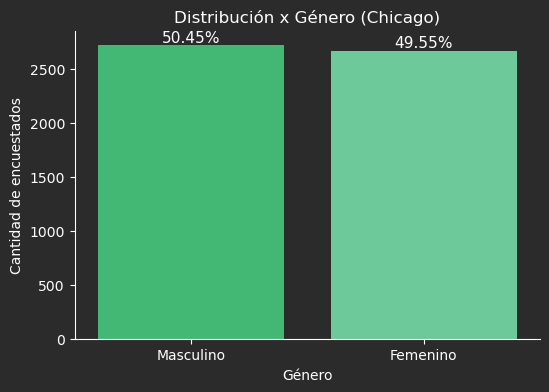

In [36]:
fig, ax = plt.subplots(figsize=(6,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b"  )

colores= ["#2ECC71", "#5DD99A"]
sns.barplot(x=conteo_genero.index, y=conteo_genero.values, palette=colores, ax=ax)


for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{round(bar.get_height() / len(df_chicago) * 100, 2)}%",
        ha="center", color="white", fontsize=11
    )

ax.set_title ("Distribución x Género (Chicago)", color="white")
ax.set_xlabel("Género",color="white")
ax.set_ylabel("Cantidad de encuestados", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### 2.2) Conteo por edad
Acá queremos conocer los rangos de edad de los encuestados

In [17]:
conteo_edad= df_chicago["edad"]
print("Edad_minima: ", df_chicago["edad"].min())
print("Edad máxima: ", df_chicago["edad"].max())
print("Edad promedio: ", round (df_chicago["edad"].mean(),1))
print("Edad mediana: ", df_chicago["edad"].median())

Edad_minima:  18.0
Edad máxima:  80.0
Edad promedio:  48.7
Edad mediana:  49.0


### Creamos un histograma para visualizar mejor por grupos de edad

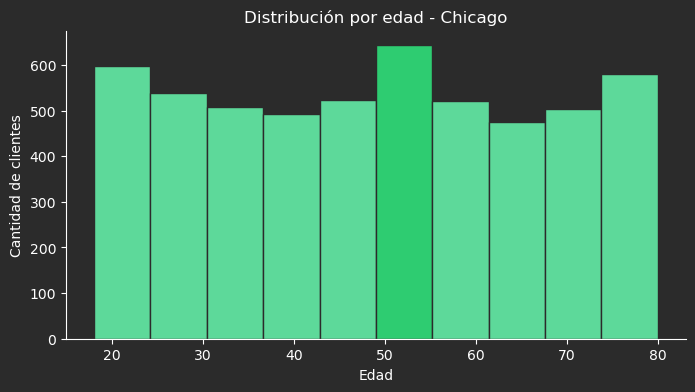

In [42]:
fig, ax = plt.subplots(figsize=(8,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

n, bins, patches = ax.hist(df_chicago["edad"], bins=10, edgecolor="#2b2b2b")

max_idx = n.argmax()

colores_degradado = ["#5DD99A", "#5DD99A", "#5DD99A", "#5DD99A", "#5DD99A", 
                     "#5DD99A", "#5DD99A", "#5DD99A", "#5DD99A", "#5DD99A"]

for i, patch in enumerate(patches):
    if i == max_idx:
        patch.set_facecolor("#2ECC71")
    else:
        patch.set_facecolor(colores_degradado[i])

ax.set_title("Distribución por edad - Chicago", color="white")
ax.set_xlabel("Edad", color="white")
ax.set_ylabel("Cantidad de clientes", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### 2.3) Rango poder adquisitivo
Acá queremos conocer cuánto % representa cada estrato socioeconomico

In [19]:
print(df_chicago["estrato_socioeconomico"].value_counts())

estrato_socioeconomico
Medio       1798
Alto        1511
Bajo        1148
Muy Alto     927
Name: count, dtype: int64


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\1513998549.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_estrato.index, y=conteo_estrato.values, palette=colores, ax=ax)


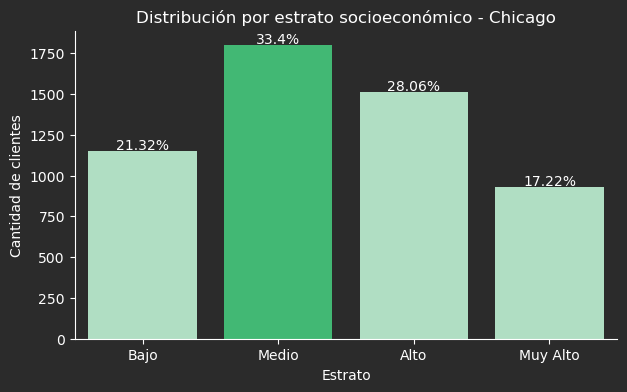

In [43]:
conteo_estrato = df_chicago["estrato_socioeconomico"].value_counts()
conteo_estrato = conteo_estrato.reindex(["Bajo", "Medio", "Alto", "Muy Alto"])

fig, ax = plt.subplots(figsize=(7,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

colores = ["#A8E6C1", "#2ECC71", "#A8E6C1", "#A8E6C1"]
sns.barplot(x=conteo_estrato.index, y=conteo_estrato.values, palette=colores, ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{round(bar.get_height() / len(df_chicago) * 100, 2)}%",
        ha="center", color="white", fontsize=10
    )

ax.set_title("Distribución por estrato socioeconómico - Chicago", color="white")
ax.set_xlabel("Estrato", color="white")
ax.set_ylabel("Cantidad de clientes", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### 2.4) preferencias alimenticias
Acá queremos conocer cuánto % representa cada estrato socioeconomico

In [21]:
df_chicago["preferencias_alimenticias"].value_counts()
df_chicago["preferencias_alimenticias"].value_counts(normalize=True).mul(100).round(2)


preferencias_alimenticias
Carnes             29.51
Vegetariano        20.86
Mariscos           12.93
Otro               10.98
Vegano             10.61
Pescado            10.14
No especificado     4.98
Name: proportion, dtype: float64

C:\Users\denny\AppData\Local\Temp\ipykernel_19868\3799976224.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_preferencias.index, y=conteo_preferencias.values, palette=colores, ax=ax)


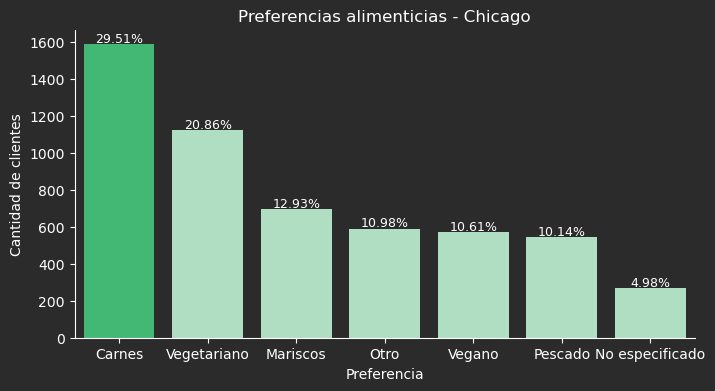

In [44]:
conteo_preferencias = df_chicago["preferencias_alimenticias"].value_counts()

fig, ax = plt.subplots(figsize=(8,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

colores = ["#2ECC71", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1"]
sns.barplot(x=conteo_preferencias.index, y=conteo_preferencias.values, palette=colores, ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{round(bar.get_height() / len(df_chicago) * 100, 2)}%",
        ha="center", color="white", fontsize=9
    )

ax.set_title("Preferencias alimenticias - Chicago", color="white")
ax.set_xlabel("Preferencia", color="white")
ax.set_ylabel("Cantidad de clientes", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

In [23]:
print(df_chicago.columns.to_list())

['id_persona', 'nombre', 'apellido', 'edad', 'genero', 'ciudad_residencia', 'estrato_socioeconomico', 'frecuencia_visita', 'promedio_gasto_comida', 'ocio', 'consume_licor', 'preferencias_alimenticias', 'membresia_premium', 'telefono_contacto', 'correo_electronico', 'tipo_de_pago_mas_usado', 'ingresos_mensuales']


In [24]:
mapeo_chicago = {
    'Vegetariano': 'Vegetariano/Vegano',
    'Vegano': 'Vegetariano/Vegano',
    'Mariscos': 'Mariscos/Pescado',
    'Pescado': 'Mariscos/Pescado',
    'Carnes': 'Carnes',
    'Otro': 'Otro',
    'No especificado': 'Otro'
}

df_chicago["categoria_estandarizada"] = df_chicago["preferencias_alimenticias"].map(mapeo_chicago)

print(df_chicago["categoria_estandarizada"].value_counts())

categoria_estandarizada
Vegetariano/Vegano    1694
Carnes                1589
Mariscos/Pescado      1242
Otro                   859
Name: count, dtype: int64


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\1759006680.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chicago["categoria_estandarizada"] = df_chicago["preferencias_alimenticias"].map(mapeo_chicago)


## 3. Análisis Final y Preguntas Clave del Negocio

Se integran los datos de la encuesta de Chicago con la información 
obtenida de la API de Yelp para responder preguntas clave que guíen 
decisiones de marketing y negocio.

### 3.1) ¿Cuánto es el promedio de gasto en restaurantes de los clientes en Chicago?

In [25]:
gasto_estrato= df_chicago.groupby("estrato_socioeconomico")["promedio_gasto_comida"].mean().round(2)
gasto_estrato = gasto_estrato.reindex(["Bajo","Medio","Alto","Muy Alto"])
print(gasto_estrato)

estrato_socioeconomico
Bajo         5.80
Medio       17.46
Alto        32.55
Muy Alto    54.17
Name: promedio_gasto_comida, dtype: float64


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\711094063.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gasto_estrato.index, y=gasto_estrato.values, palette=colores, ax=ax)


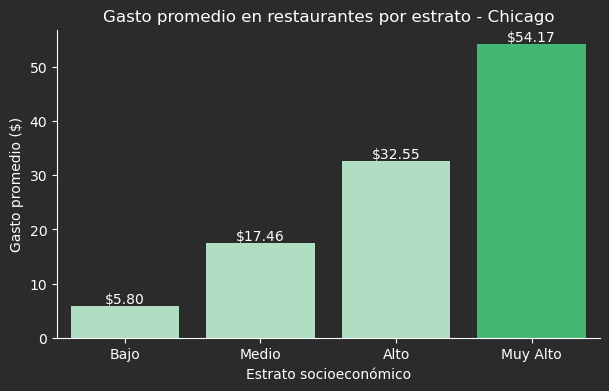

In [45]:
fig, ax = plt.subplots(figsize=(7,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

colores = ["#A8E6C1", "#A8E6C1", "#A8E6C1", "#2ECC71"]
sns.barplot(x=gasto_estrato.index, y=gasto_estrato.values, palette=colores, ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"${bar.get_height():.2f}",
        ha="center", color="white", fontsize=10
    )

ax.set_title("Gasto promedio en restaurantes por estrato - Chicago", color="white")
ax.set_xlabel("Estrato socioeconómico", color="white")
ax.set_ylabel("Gasto promedio ($)", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Conclusión
En la gráfica se observa una relación directamente proporcional entre el estrato socioeconómico y el gasto promedio en restaurantes.

A medida que aumenta el nivel socioeconómico de los clientes, incrementa de forma consistente el monto promedio que destinan al consumo en restaurantes:
En términos de análisis, esta tendencia puede ser útil para:

- Segmentar estrategias de precios.
- Diseñar ofertas dirigidas por perfil socioeconómico.
- Entender el potencial de ingreso por zona o tipo de cliente.

### 3.2) Relación entre frecuencia de visita y gasto promedio según estrato socioeconomico 

In [27]:

relacion_visita_gasto = df_chicago[df_chicago["frecuencia_visita"] > 0].groupby(["estrato_socioeconomico", "frecuencia_visita"])["promedio_gasto_comida"].mean().round(2).unstack()
relacion_visita_gasto = relacion_visita_gasto.reindex(["Bajo", "Medio", "Alto", "Muy Alto"])

print (relacion_visita_gasto)

frecuencia_visita       1.0    2.0    3.0    4.0    5.0    6.0    7.0    8.0   \
estrato_socioeconomico                                                          
Bajo                    7.46   7.43   7.65   7.70    NaN    NaN    NaN    NaN   
Medio                    NaN  17.10  17.07  17.80  17.72    NaN    NaN    NaN   
Alto                     NaN    NaN    NaN  32.92  32.93  31.75    NaN    NaN   
Muy Alto                 NaN    NaN    NaN  51.94  49.60  53.09  53.76  56.07   

frecuencia_visita        9.0    10.0  
estrato_socioeconomico                
Bajo                      NaN    NaN  
Medio                     NaN    NaN  
Alto                      NaN    NaN  
Muy Alto                53.82  59.77  


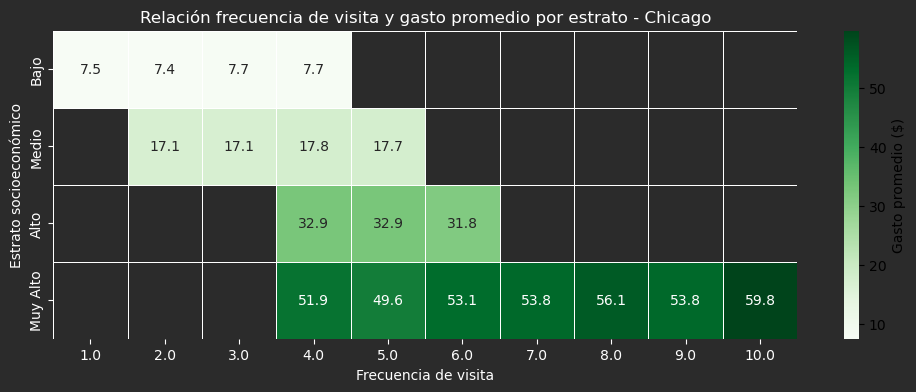

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

sns.heatmap(
    relacion_visita_gasto,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Gasto promedio ($)"}
)

ax.set_title("Relación frecuencia de visita y gasto promedio por estrato - Chicago", color="white")
ax.set_xlabel("Frecuencia de visita", color="white")
ax.set_ylabel("Estrato socioeconómico", color="white")
ax.tick_params(colors="white")

plt.show()

### Conclusión
Un cliente de estrato Bajo visita el restaurante entre 1 y 4 veces 
gastando aproximadamente $7 por visita. En contraste, un cliente de 
estrato Muy Alto visita entre 4 y 10 veces con un gasto mínimo de $50 
por visita, lo que los convierte en el segmento más rentable para el negocio.

### 3.3) Relación entre frecuencia de visita y gasto promedio según estrato socioeconomico 

In [29]:
clientes_alto_gasto = df_chicago[df_chicago["estrato_socioeconomico"].isin(["Alto", "Muy Alto"])]

print("Cantidad de clientes de alto gasto:", len(clientes_alto_gasto))
print()

print(clientes_alto_gasto["preferencias_alimenticias"].value_counts())
print()
print("Gasto promedio:", round(clientes_alto_gasto["promedio_gasto_comida"].mean(), 2))
print("Gasto máximo:", clientes_alto_gasto["promedio_gasto_comida"].max())
print("Gasto mínimo:", clientes_alto_gasto["promedio_gasto_comida"].min())

Cantidad de clientes de alto gasto: 2438

preferencias_alimenticias
Carnes             693
Vegetariano        511
Mariscos           323
Otro               274
Vegano             266
Pescado            251
No especificado    120
Name: count, dtype: int64

Gasto promedio: 40.81
Gasto máximo: 104.92
Gasto mínimo: 5.06


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\2196940587.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_alto_gasto.index, y=conteo_alto_gasto.values, palette=colores, ax=ax)


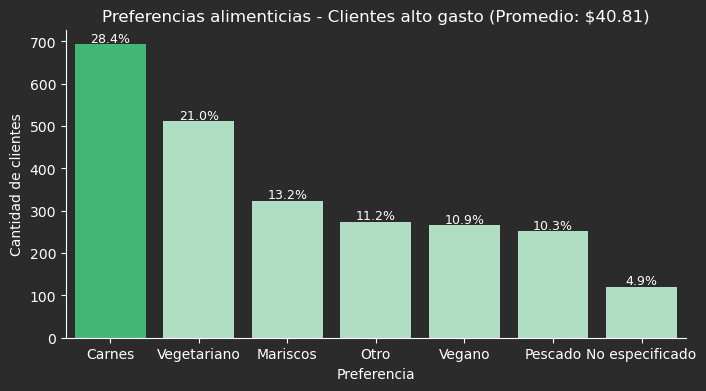

In [51]:
fig, ax = plt.subplots(figsize=(8,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

conteo_alto_gasto = clientes_alto_gasto["preferencias_alimenticias"].value_counts()
colores = ["#2ECC71", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1", "#A8E6C1"]
sns.barplot(x=conteo_alto_gasto.index, y=conteo_alto_gasto.values, palette=colores, ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{round(bar.get_height() / len(clientes_alto_gasto) * 100, 1)}%",
        ha="center", color="white", fontsize=9
    )

ax.set_title(f"Preferencias alimenticias - Clientes alto gasto (Promedio: ${40.81})", color="white")
ax.set_xlabel("Preferencia", color="white")
ax.set_ylabel("Cantidad de clientes", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Conclusión
Los clientes de alto gasto (estratos Alto y Muy Alto) tienen un gasto 
promedio de $40.81. Su preferencia principal son las Carnes (28.4%), 
seguido de opciones Vegetarianas (21%) y Mariscos (13.2%).
Esto sugiere que los restaurantes de carnes y opciones vegetarianas 
premium tienen mayor potencial de captación en este segmento.

### 3.4) membresías premium

In [31]:
print(df_chicago["membresia_premium"].value_counts())
print()
print(df_chicago["membresia_premium"].value_counts(normalize=True).mul(100).round(2))

membresia_premium
No    3169
Sí    2215
Name: count, dtype: int64

membresia_premium
No    58.86
Sí    41.14
Name: proportion, dtype: float64


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\204543361.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_membresia.index, y=conteo_membresia.values, palette=colores, ax=ax)


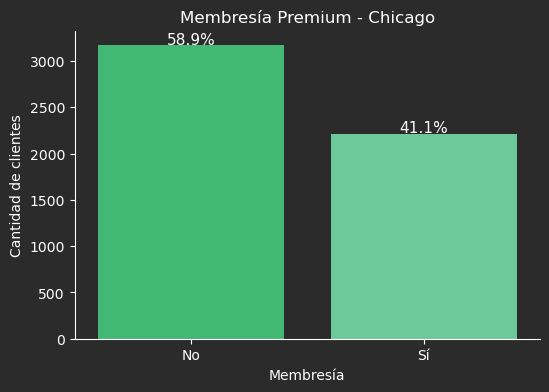

In [53]:
conteo_membresia = df_chicago["membresia_premium"].value_counts()

fig, ax = plt.subplots(figsize=(6,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

colores = ["#2ECC71", "#5DD99A"]
sns.barplot(x=conteo_membresia.index, y=conteo_membresia.values, palette=colores, ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{round(bar.get_height() / len(df_chicago) * 100, 1)}%",
        ha="center", color="white", fontsize=11
    )

ax.set_title("Membresía Premium - Chicago", color="white")
ax.set_xlabel("Membresía", color="white")
ax.set_ylabel("Cantidad de clientes", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Conclusión
El 41.14% de los clientes de Chicago cuenta con membresía premium, 
lo que representa un segmento significativo y fidelizado. 
Esto sugiere una oportunidad para diseñar campañas exclusivas 
dirigidas a este grupo con beneficios diferenciados

### 3.5) Relación entre consumo de alcohol y edad


In [33]:
print(df_chicago["consume_licor"].value_counts())
print()
print(df_chicago.groupby("consume_licor")["edad"].mean().round(1))


consume_licor
Sí    3375
No    2009
Name: count, dtype: int64

consume_licor
No    53.5
Sí    45.9
Name: edad, dtype: float64


C:\Users\denny\AppData\Local\Temp\ipykernel_19868\2218950044.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


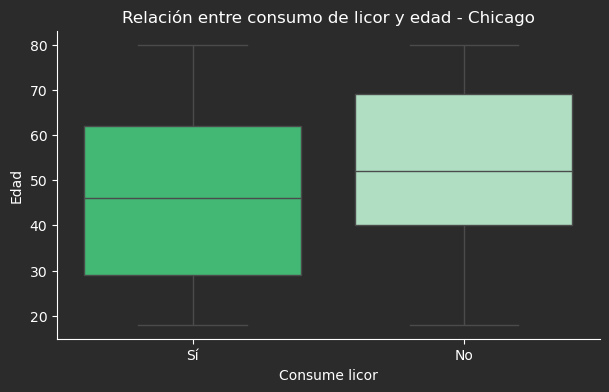

In [54]:
fig, ax = plt.subplots(figsize=(7,4))
fig.patch.set_facecolor("#2b2b2b")
ax.set_facecolor("#2b2b2b")

sns.boxplot(
    data=df_chicago,
    x="consume_licor",
    y="edad",
    palette=["#2ECC71", "#A8E6C1"],
    ax=ax
)

ax.set_title("Relación entre consumo de licor y edad - Chicago", color="white")
ax.set_xlabel("Consume licor", color="white")
ax.set_ylabel("Edad", color="white")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Conclusión
Los clientes que consumen licor tienden a ser más jóvenes, 
con una mediana de edad de 47 años, mientras que los que 
no consumen licor tienen una mediana de 52 años. 
Esto sugiere que las estrategias de promoción de bebidas 
alcohólicas deberían enfocarse en el segmento de clientes 
menores de 50 años.

In [55]:
df_yelp= pd.read_csv("df_api_yelp_limpio.csv")

In [61]:
df_yelp= pd.read_csv("df_api_yelp_limpio.csv")

#Mejor restuarante por categoria
mejor_por_categoria= (
    df_yelp.sort_values("rating_ponderado",ascending=False)
    .drop_duplicates(subset="name")
    .groupby("categoria_estandarizada")["name"]
    .first()
    .reset_index()
    .rename(columns={"name":"recomendacion"})
)

#Agregar columna a Chicago
df_chicago_recomendaciones = df_chicago.merge(mejor_por_categoria, on="categoria_estandarizada", how="left")

display(df_chicago_recomendaciones[["nombre", "apellido", "preferencias_alimenticias", "recomendacion"]].head(10))

,nombre,apellido,preferencias_alimenticias,recomendacion
0,Richard,Adams,Vegetariano,Ciccio Mio
1,Leah,Cooper,Mariscos,Omakase Shoji
2,Jennifer,Richardson,Carnes,Penumbra
3,Alyssa,Bryant,Vegetariano,Ciccio Mio
4,Michael,Cochran,Pescado,Omakase Shoji
5,John,Simon,Pescado,Omakase Shoji
6,Michael,Martinez,Mariscos,Omakase Shoji
7,Kelly,Travis,Vegano,Ciccio Mio
8,Holly,Hunter,Vegetariano,Ciccio Mio
9,Gary,Nguyen,Mariscos,Omakase Shoji


## Recomendaciones de restaurantes

Se generan dos tablas de recomendaciones para los clientes de Chicago:

- **df_chicago_recomendaciones:** cada cliente tiene asignado el restaurante 
con mayor rating ponderado según su preferencia alimenticia.

- **top3_por_categoria:** para cada categoría se muestran los 3 mejores 
restaurantes disponibles, que pueden usarse como alternativas de recomendación 
para los clientes de esa misma categoría.

In [62]:
top3_por_categoria = (
    df_yelp.sort_values("rating_ponderado", ascending=False)
    .drop_duplicates(subset="name")
    .groupby("categoria_estandarizada").head(3)
    [["categoria_estandarizada", "name", "rating_ponderado", "location_address1"]]
    .sort_values(["categoria_estandarizada", "rating_ponderado"], ascending=[True, False])
)

display(top3_por_categoria)

,categoria_estandarizada,name,rating_ponderado,location_address1
18,Carnes,Penumbra,4.661038,3309 W Fullerton Ave
61,Carnes,XOchimilco Mexican Restaurant,4.552363,2030-32 W Montrose Ave
89,Carnes,Amaru,4.534211,1904 W North Ave
202,Mariscos/Pescado,Omakase Shoji,4.412982,1641 W Chicago Ave
115,Mariscos/Pescado,Sho,4.385347,1533 N Wells St
175,Mariscos/Pescado,Chef’s Special Cocktail Bar,4.385274,2165 N Western Ave
247,Otro,Cedar Palace,4.593515,655 W Armitage Ave
214,Otro,En Hakkore 2.0,4.499757,1467 N Milwaukee Ave
182,Otro,The Soul Food Lounge,4.480093,3804 W 16th St
12,Vegetariano/Vegano,Ciccio Mio,4.556346,226 W Kinzie
